In [1]:
from sklearn.datasets import make_regression
import numpy as np


In [3]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=4,
    n_features=1,
    n_informative=1,
    n_targets=1,
    noise=8,
    random_state=1
)

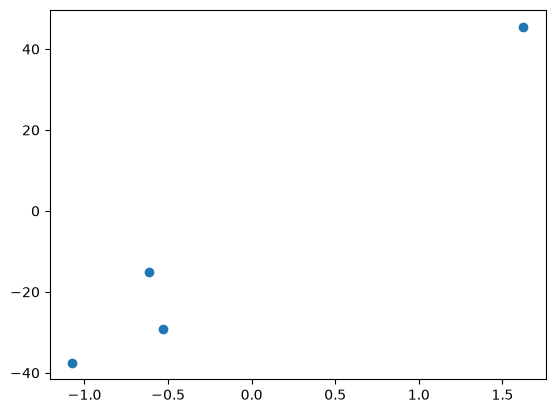

In [7]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[30.65]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.544
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[2.09]


In [8]:
print("Coefficient:", reg.coef_)
print("Intercept:", reg.intercept_)

Coefficient: [30.6473641]
Intercept: -4.544115263199093


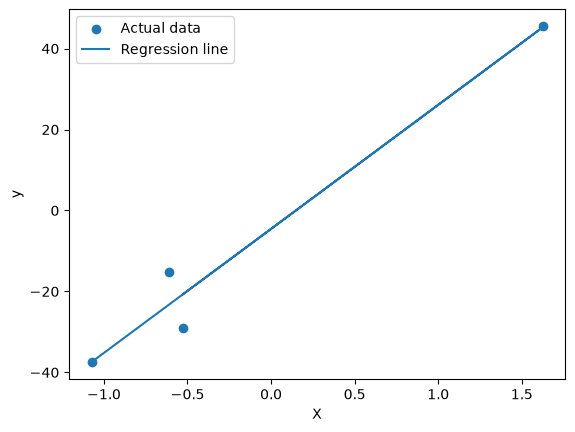

In [11]:
plt.scatter(X, y, label="Actual data")
plt.plot(X, reg.predict(X), label="Regression line")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [15]:
m = 0
b = 0

learning_rate = 0.01
epochs = 1000

X_flat = X.ravel()

loss_history = []

for i in range(epochs):

    y_pred = m * X_flat + b
    print(f"Epoch {i+1}: Predicted values: {y_pred}")
    error = y - y_pred
    print(f"Epoch {i+1}: Error: {error}")
    loss = np.mean(error ** 2)
    loss_history.append(loss)
    print(f"Epoch {i+1}: Loss: {loss}")
    dm = -2 * np.mean(error * X_flat)
    db = -2 * np.mean(error)
    print(f"Epoch {i+1}: Gradient w.r.t m: {dm}, Gradient w.r.t b: {db}")
    m = m - learning_rate * dm
    b = b - learning_rate * db
    print(f"Epoch {i+1}: Updated m: {m}, Updated b: {b}")
    

print("\nGRADIENT DESCENT")
print("Slope:", m)
print("Intercept:", b)
print("Final Loss:", loss_history[-1])

Epoch 1: Predicted values: [0. 0. 0. 0.]
Epoch 1: Error: [-37.4730105  -15.18974193  45.54099188 -29.0922503 ]
Epoch 1: Loss: 1138.8239363061357
Epoch 1: Gradient w.r.t m: -69.41989516650708, Gradient w.r.t b: 18.10700542297299
Epoch 1: Updated m: 0.6941989516650707, Updated b: -0.18107005422972988
Epoch 2: Predicted values: [-0.92592375 -0.60575072  0.94654879 -0.54772633]
Epoch 2: Error: [-36.54708675 -14.58399121  44.59444309 -28.54452397]
Epoch 2: Loss: 1087.959138269933
Epoch 2: Gradient w.r.t m: -67.82445779967867, Gradient w.r.t b: 17.540579423601557
Epoch 2: Updated m: 1.3724435296618576, Updated b: -0.3564758484657454
Epoch 3: Predicted values: [-1.82906469 -1.19607698  1.87284644 -1.08136175]
Epoch 3: Error: [-35.64394581 -13.99366495  43.66814545 -28.01088855]
Epoch 3: Loss: 1039.4575839336608
Epoch 3: Gradient w.r.t m: -66.26612969543643, Gradient w.r.t b: 16.99017692889154
Epoch 3: Updated m: 2.035104826616222, Updated b: -0.5263776177546609
Epoch 4: Predicted values: [-2.

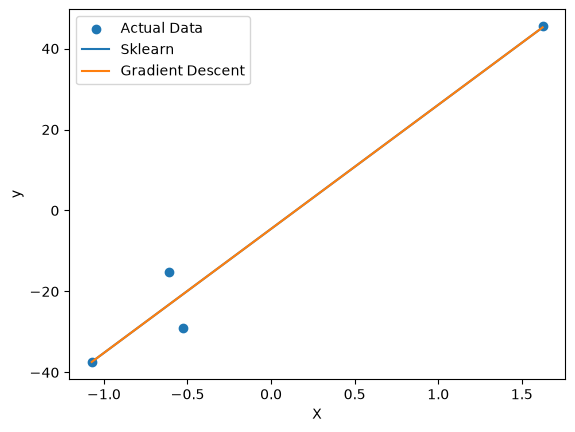

In [16]:
plt.scatter(X, y, label="Actual Data")

order = np.argsort(X_flat)
X_sorted = X_flat[order]

y_sklearn = reg.predict(X[order])

y_gd = m * X_sorted + b

plt.plot(X_sorted, y_sklearn, label="Sklearn")
plt.plot(X_sorted, y_gd, label="Gradient Descent")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()